# FOOD PRICE STABILITY PREDICTIVE ANALYTICS

---



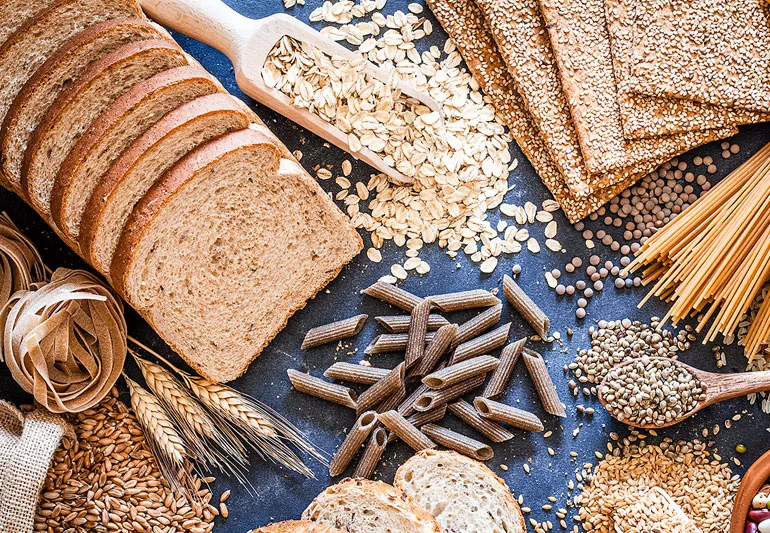

## PROJECT OVERVIEW

---



Food pricing is one of the key factors that determine access to food. An increase in food prices reduces the purchasing power and therefore limits the quantity of food that can be purchased. The food inflation rate has more than doubled in the past year to 13.8% as of June 2022 from 6.32% in June 2021.Some of the items in the food basket driving food inflation include wheat, cooking oil, maize flour, milk, potatoes, onion and carrot. The highest average price change is recorded for maize flour at 67% Kenyans through social media campaigns have been pressuring the government into taking specific actions on food prices.These unpredictable fluctuations create a destabilizing cycle for both consumers and producers, as the market rapidly oscillates between wasteful surpluses and acute shortages.  


This project seeks to mitigate these imbalances by utilizing time-series forecasting to provide reliable price predictions. By delivering actionable insights such as forecasting the value of a 90kg bag of maize half a year into the future the model empowers farmers in regions like Uasin Gishu to make informed, data-driven decisions on whether to maintain current crop cycles or pivot to more viable alternatives.  

## Business Understanding

The agricultural sector plays a major role in Kenya’s economy and food supply. However, unstable food prices create uncertainty for farmers, consumers, businesses, and government agencies.

Many stakeholders currently rely on traditional experience and manual estimation methods instead of predictive systems. This limits their ability to prepare for shortages, inflation, or surplus production.

The purpose of this project is to provide predictive insights that support better planning and reduce the negative impact of food price volatility.

## Problem Description

Food prices in Kenya often fluctuate due to changing weather conditions, fuel price changes, transportation costs, and seasonal farming cycles. These fluctuations can lead to:

- High food costs for consumers
- Losses for farmers during surplus seasons
- Poor planning and budgeting
- Food insecurity in vulnerable regions

Currently, there are limited intelligent systems that use historical and external data to forecast food prices accurately.

This project aims to solve this problem by building a machine learning-based predictive system capable of forecasting future prices of key food commodities.

## Project Objectives

### Primary Objective
To develop a predictive analytics model that forecasts the prices of key food commodities in Kenya, including maize, milk, and beans.

### Secondary Objectives
- Analyze historical food price trends
- Study the effect of rainfall on food prices
- Study the impact of fuel prices on transportation and food costs
- Improve prediction accuracy using external variables
- Develop an interactive Streamlit dashboard for visualization and forecasting

## Why the Project Matters

Food price instability directly affects economic stability, household budgeting, and agricultural planning in Kenya.

This project is important because it can:
- Help farmers make better planting and selling decisions
- Help consumers prepare for future price changes
- Support government policy and food security planning
- Reduce losses caused by poor market timing
- Encourage data-driven agricultural decision-making

## Stakeholders

### Consumers
Consumers can use the predictions for budgeting and planning household expenses.

### Farmers and Agricultural Saccos
Farmers can use predicted prices to decide when to plant, harvest, store, or sell their produce.

### Government Agencies
Organizations such as the Ministry of Agriculture and NCPB can use the system for food security monitoring and policy planning.

### Insurance Providers
Insurance companies can use predictive insights for agricultural risk assessment and pricing strategies.

## Expected Outcomes

The project is expected to produce:
- Accurate food price prediction models
- Identification of seasonal price patterns
- Insights into how rainfall and fuel prices affect food prices
- Interactive dashboards and visualizations
- Early warning indicators for possible price spikes
- A deployed Streamlit web application for users

## Potential Impact

The system has the potential to improve decision-making across the agricultural supply chain.

Potential impacts include:
- Improved farm productivity and planning
- Better consumer financial planning
- Reduced market inefficiencies
- Increased food security awareness
- Enhanced use of data analytics in agriculture

## Key Deliverables

The project deliverables include:

1. Cleaned and merged datasets
2. Exploratory Data Analysis (EDA)
3. Feature engineering and preprocessing pipeline
4. Machine learning prediction models
5. Model evaluation results using MAE and RMSE
6. Data visualizations and trend analysis
7. Streamlit web application
8. Final project report and presentation

## Data Understanding

### Import Libraries

The project begins by importing the necessary Python libraries for data analysis, visualization, preprocessing, and machine learning.

In [66]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

### Load Datasets

The datasets are loaded into pandas DataFrames for analysis and preprocessing.

The project uses:
- Food prices dataset
- Rainfall dataset
- Fuel prices dataset

In [67]:
food = pd.read_csv("wfp_food_prices_ken.csv")

rainfall= pd.read_csv("ken-rainfall-subnat-full.csv")

fuel = pd.read_csv("Pump Prices Energy and Petroleum Regulatory Authority.csv")

## Create Dataset Copies

Copies of the original datasets are created to avoid modifying the raw data directly.

In [68]:
food_df = food.copy()

rainfall_df = rainfall.copy()

fuel_df = fuel.copy()

#### Preview the Datasets

The first few rows are displayed to understand the structure and contents of each dataset.

In [69]:
food_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19005 entries, 0 to 19004
Data columns (total 16 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   date          19005 non-null  object 
 1   admin1        18966 non-null  object 
 2   admin2        18966 non-null  object 
 3   market        19005 non-null  object 
 4   market_id     19005 non-null  int64  
 5   latitude      18966 non-null  float64
 6   longitude     18966 non-null  float64
 7   category      19005 non-null  object 
 8   commodity     19005 non-null  object 
 9   commodity_id  19005 non-null  int64  
 10  unit          19005 non-null  object 
 11  priceflag     19005 non-null  object 
 12  pricetype     19005 non-null  object 
 13  currency      19005 non-null  object 
 14  price         19005 non-null  float64
 15  usdprice      19005 non-null  float64
dtypes: float64(4), int64(2), object(10)
memory usage: 2.3+ MB


In [70]:
rainfall_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 132273 entries, 0 to 132272
Data columns (total 15 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   date       132273 non-null  object 
 1   adm_level  132273 non-null  int64  
 2   adm_id     132273 non-null  int64  
 3   PCODE      132273 non-null  object 
 4   n_pixels   132273 non-null  float64
 5   rfh        132273 non-null  float64
 6   rfh_avg    132273 non-null  float64
 7   r1h        132111 non-null  float64
 8   r1h_avg    132111 non-null  float64
 9   r3h        131625 non-null  float64
 10  r3h_avg    131625 non-null  float64
 11  rfq        132273 non-null  float64
 12  r1q        132111 non-null  float64
 13  r3q        131625 non-null  float64
 14  version    132273 non-null  object 
dtypes: float64(10), int64(2), object(3)
memory usage: 15.1+ MB


In [71]:
fuel_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 197 entries, 0 to 196
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Date           197 non-null    object 
 1   Town           197 non-null    object 
 2   Super (PMS)    197 non-null    float64
 3   Diesel (AGO)   197 non-null    float64
 4   Kerosene (IK)  197 non-null    float64
dtypes: float64(3), object(2)
memory usage: 7.8+ KB


#### Dataset Shape

The shape of each dataset is checked to understand the number of rows and columns available.

In [72]:
print("Food Prices Shape:", food_df.shape)

print("Rainfall Shape:", rainfall_df.shape)

print("Fuel Prices Shape:", fuel_df.shape)

Food Prices Shape: (19005, 16)
Rainfall Shape: (132273, 15)
Fuel Prices Shape: (197, 5)


# Data Cleaning
Check for missing values and imputing them  
Checking for duplicates  
Drop irrelevant columns  
Check for outliers and handling them in the data

#### 1). Missing values

In [73]:
food_df.isnull().sum()

,0
date,0
admin1,39
admin2,39
market,0
market_id,0
latitude,39
longitude,39
category,0
commodity,0
commodity_id,0


In [74]:
#Fake/imputed latitude and longitude can create wrong geographic analysis
#Dropping 39 rows won’t hurt your model
food_df = food_df.dropna(
    subset=['admin1', 'admin2', 'latitude', 'longitude']
)

In [75]:
food_df.isnull().sum()

,0
date,0
admin1,0
admin2,0
market,0
market_id,0
latitude,0
longitude,0
category,0
commodity,0
commodity_id,0


In [76]:
rainfall_df.isnull().sum()

,0
date,0
adm_level,0
adm_id,0
PCODE,0
n_pixels,0
rfh,0
rfh_avg,0
r1h,162
r1h_avg,162
r3h,648


In [77]:
rainfall_df.fillna(rainfall_df.median(numeric_only=True), inplace=True)

In [78]:
rainfall_df.isnull().sum()

,0
date,0
adm_level,0
adm_id,0
PCODE,0
n_pixels,0
rfh,0
rfh_avg,0
r1h,0
r1h_avg,0
r3h,0


In [79]:
fuel_df.isnull().sum()

,0
Date,0
Town,0
Super (PMS),0
Diesel (AGO),0
Kerosene (IK),0


### 2).Checking for duplicates

In [80]:
food_df.duplicated().sum()


np.int64(0)

In [81]:
rainfall_df.duplicated().sum()


np.int64(0)

In [82]:
rainfall_df.duplicated().sum()

np.int64(0)

# 3).Feature Selection & Dropping Irrelevant Columns

#### Drop Irrelevant Columns from Food Dataset

Columns such as IDs, latitude, longitude, currency details, and unnecessary metadata are removed.

In [83]:
food_df.columns

Index(['date', 'admin1', 'admin2', 'market', 'market_id', 'latitude',
       'longitude', 'category', 'commodity', 'commodity_id', 'unit',
       'priceflag', 'pricetype', 'currency', 'price', 'usdprice'],
      dtype='object')

In [84]:
food_df.drop(columns=[
    'adm1_id',
    'adm2_id',
    'market_id',
    'commodity_id',
    'latitude',
    'longitude',
    'currency',
    'usdprice',
    'priceflag',
], inplace=True, errors='ignore')

### Filter food data to include records from Jan, 2010 - Jan, 2026.

In [85]:
food_df['date'] = pd.to_datetime(food_df['date'])
food_df['date'] = food_df['date'].dt.to_period('M').dt.to_timestamp()
food_df = food_df[(food_df['date'] >= '2010-01-01') &
                         (food_df['date'] <= '2026-01-31')]

In [86]:
# 1. Ensure date is in the '1st of the month' format (Timestamp)
food_df['date'] = food_df['date'].dt.to_period('M').dt.to_timestamp()

# 2. Group by Date, County (admin2), and Commodity
# We aggregate the 'price' by mean
food_df = food_df.groupby(['date', 'admin2', 'commodity', 'pricetype']).agg({
    'price': 'mean'
}).reset_index()

In [87]:
food_district_to_county = {
    'Meru South': 'Tharaka-Nithi',
    'Moyale': 'Marsabit',
    'Meru North': 'Meru',
    'Ijara': 'Garissa'
}
food_df['admin2'] = food_df['admin2'].replace(food_district_to_county)

In [88]:
food_df.head()

,date,admin2,commodity,pricetype,price
0,2010-01-01,Kisumu,Beans,Wholesale,50.55
1,2010-01-01,Kisumu,Beans (dry),Wholesale,4608.00
2,2010-01-01,Kisumu,Maize,Wholesale,26.41
3,2010-01-01,Kisumu,Maize (white),Wholesale,2395.00
4,2010-01-01,Kisumu,Potatoes (Irish),Wholesale,1360.00


#### Drop Irrelevant Columns from Rainfall Dataset

Only rainfall-related features necessary for analysis are retained.

In [89]:
rainfall_df.columns

Index(['date', 'adm_level', 'adm_id', 'PCODE', 'n_pixels', 'rfh', 'rfh_avg',
       'r1h', 'r1h_avg', 'r3h', 'r3h_avg', 'rfq', 'r1q', 'r3q', 'version'],
      dtype='object')

In [90]:
rainfall_df.drop(columns=[
    'pcode',
    'n_pixels',
    'version'
], inplace=True, errors='ignore')

In [91]:
rainfall_df['PCODE'].unique()

array(['KE019', 'KE004', 'KE010', 'KE047', 'KE008', 'KE043', 'KE023',
       'KE037', 'KE022122', 'KE020101', 'KE021107', 'KE021104',
       'KE018090', 'KE019095', 'KE021110', 'KE003015', 'KE002010',
       'KE005022', 'KE003017', 'KE001003', 'KE006026', 'KE004018',
       'KE014064', 'KE011049', 'KE015074', 'KE016075', 'KE017088',
       'KE010046', 'KE014065', 'KE012057', 'KE012053', 'KE013060',
       'KE010045', 'KE015067', 'KE013062', 'KE047277', 'KE007031',
       'KE007032', 'KE009041', 'KE008038', 'KE041236', 'KE045266',
       'KE045264', 'KE043250', 'KE042241', 'KE044259', 'KE044258',
       'KE046273', 'KE042243', 'KE043247', 'KE041234', 'KE043252',
       'KE030157', 'KE036195', 'KE036198', 'KE034185', 'KE028150',
       'KE035188', 'KE030161', 'KE031165', 'KE028147', 'KE032168',
       'KE033182', 'KE025135', 'KE033177', 'KE026137', 'KE023124',
       'KE027143', 'KE024131', 'KE039224', 'KE040230', 'KE037206',
       'KE037201', 'KE037199', 'KE039216', 'KE040226', 'KE0382

#### We change our rainfall data to show month-to-month changes instead of 10-day changes originally shown. This mathes our fuel and food prices records.

In [92]:
rainfall_df['date'] = pd.to_datetime(rainfall_df['date'])


rainfall_df = rainfall_df.groupby(['PCODE', pd.Grouper(key='date', freq='MS')]).agg({
    'rfh': 'mean',
    'r3q': 'mean'
}).reset_index()

In [93]:
# Map PCODE to County
pcode_to_county = {
    'KE001': 'Mombasa',
    'KE002': 'Kwale',
    'KE003': 'Kilifi',
    'KE004': 'Tana River',
    'KE005': 'Lamu',
    'KE006': 'Taita Taveta',
    'KE007': 'Garissa',
    'KE008': 'Wajir',
    'KE009': 'Mandera',
    'KE010': 'Marsabit',
    'KE011': 'Isiolo',
    'KE012': 'Meru',
    'KE013': 'Tharaka-Nithi',
    'KE014': 'Embu',
    'KE015': 'Kitui',
    'KE016': 'Machakos',
    'KE017': 'Makueni',
    'KE018': 'Nyandarua',
    'KE019': 'Nyeri',
    'KE020': 'Kirinyaga',
    'KE021': 'Murang\'a',
    'KE022': 'Kiambu',
    'KE023': 'Turkana',
    'KE024': 'West Pokot',
    'KE025': 'Samburu',
    'KE026': 'Trans Nzoia',
    'KE027': 'Uasin Gishu',
    'KE028': 'Elgeyo-Marakwet',
    'KE029': 'Nandi',
    'KE030': 'Baringo',
    'KE031': 'Laikipia',
    'KE032': 'Nakuru',
    'KE033': 'Narok',
    'KE034': 'Kajiado',
    'KE035': 'Kericho',
    'KE036': 'Bomet',
    'KE037': 'Kakamega',
    'KE038': 'Vihiga',
    'KE039': 'Bungoma',
    'KE040': 'Busia',
    'KE041': 'Siaya',
    'KE042': 'Kisumu',
    'KE043': 'Homa Bay',
    'KE044': 'Migori',
    'KE045': 'Kisii',
    'KE046': 'Nyamira',
    'KE047': 'Nairobi'
}

In [94]:
rainfall_df['admin2'] = rainfall_df['PCODE'].str[:5].map(pcode_to_county)

### We apply three month lag on rainfall data.
### Logic: A drought today will take time to affect food prices

In [95]:
# Sort
rainfall_df = rainfall_df.sort_values(['admin2', 'date'])

# Create the lag
rainfall_df['r3q_lag_3'] = rainfall_df.groupby('admin2')['r3q'].shift(3)

# Drop the first 3 months of each county
rainfall_df.dropna(subset=['r3q_lag_3'], inplace=True)

In [96]:
rainfall_df = rainfall_df.groupby(['date', 'admin2']).agg({
    'rfh': 'mean',
    'r3q': 'mean',
    'r3q_lag_3': 'mean'
}).reset_index()

### Filter rainfall data to include data from Jan, 2020 - Jan, 2026.

In [97]:
rainfall_df = rainfall_df[(rainfall_df['date'] >= '2010-01-01') &
                                (rainfall_df['date'] <= '2026-01-31')]

In [98]:
rainfall_df.head()

,date,admin2,rfh,r3q,r3q_lag_3
16270,2010-01-01,Baringo,13.195382,152.537645,93.318548
16271,2010-01-01,Bomet,32.248743,116.703338,90.185372
16272,2010-01-01,Bungoma,16.238889,135.115528,101.485251
16273,2010-01-01,Busia,22.465686,128.606749,102.985153
16274,2010-01-01,Elgeyo-Marakwet,17.227509,136.974687,86.666505


In [99]:
rainfall_df[rainfall_df['admin2'].notnull()]['admin2'].value_counts()

,count
admin2,
Baringo,193
Bomet,193
Bungoma,193
Busia,193
Elgeyo-Marakwet,193
Embu,193
Garissa,193
Homa Bay,193
Isiolo,193


### Fuel Dataset Feature Selection

- The fuel dataset already contains relevant columns required for the project.
- We will however filter our data to include diesel only as it is majorly used food transportation in Kenya.
- We also filter the fuel data to include records from Jan, 2010 - Jan, 2026.

In [100]:
fuel_df = fuel_df.drop(columns=['Town','Super (PMS)', 'Kerosene (IK)'], axis=1)

In [101]:
# Filter for 2010 - 2026
fuel_df['Date'] = pd.to_datetime(fuel_df['Date'])

fuel_df['Date'] = fuel_df['Date'].dt.to_period('M').dt.to_timestamp()
fuel_df = fuel_df[(fuel_df['Date'] >= '2010-01-01') &
                    (fuel_df['Date'] <= '2026-01-31')]

/tmp/ipykernel_7743/2101879827.py:2: UserWarning: Parsing dates in %d/%m/%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  fuel_df['Date'] = pd.to_datetime(fuel_df['Date'])


In [102]:
fuel_df = fuel_df.rename(columns={'Date': 'date','Diesel (AGO)' : 'diesel_price'})
fuel_df.head()

,date,diesel_price
4,2026-01-01,170.47
5,2025-12-01,171.47
6,2025-11-01,171.47
7,2025-10-01,171.47
8,2025-09-01,171.47


### 4). Investigating outliers

#### Visualize Outliers Using Boxplots

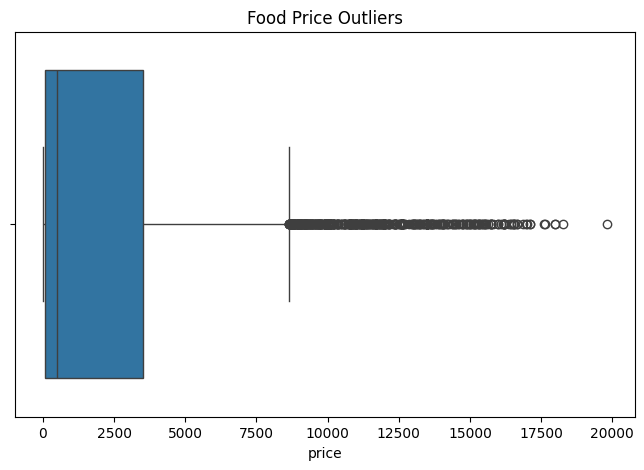

In [103]:
plt.figure(figsize=(8,5))
sns.boxplot(x=food_df['price'])

plt.title("Food Price Outliers")
plt.show()

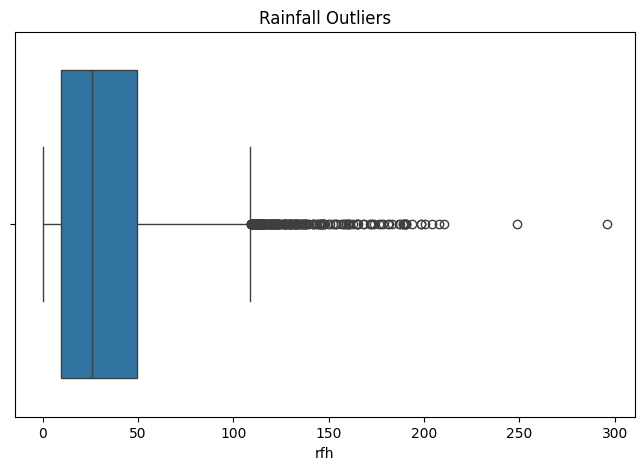

In [104]:
plt.figure(figsize=(8,5))
sns.boxplot(x=rainfall_df['rfh'])

plt.title("Rainfall Outliers")
plt.show()

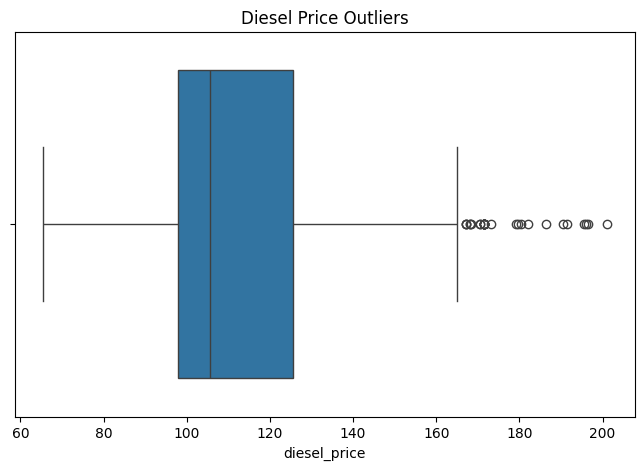

In [105]:
plt.figure(figsize=(8,5))
sns.boxplot(x=fuel_df['diesel_price'])

plt.title("Diesel Price Outliers")
plt.show()

### Detect Outliers Using IQR

In [106]:
Q1 = food_df['price'].quantile(0.25)
Q3 = food_df['price'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

food_df = food_df[
    (food_df['price'] >= lower) &
    (food_df['price'] <= upper)
]

# Merge Datasets

The datasets are merged to combine food prices, rainfall information, and fuel prices into a single analytical dataset.

The merge is performed using common time-related features such as year and month.

In [107]:
# Convert to datetime
food_df['date'] = pd.to_datetime(food_df['date'])
rainfall_df['date'] = pd.to_datetime(rainfall_df['date'])
fuel_df['date'] = pd.to_datetime(fuel_df['date'])

In [108]:
# Create year and month columns
food_df['year'] = food_df['date'].dt.year
food_df['month'] = food_df['date'].dt.month

rainfall_df['year'] = rainfall_df['date'].dt.year
rainfall_df['month'] = rainfall_df['date'].dt.month

fuel_df['year'] = fuel_df['date'].dt.year
fuel_df['month'] = fuel_df['date'].dt.month

In [109]:
# # Rename important columns
# rainfall_df.rename(columns={
#     'rfh_avg': 'rainfall_avg'
# }, inplace=True)

# fuel_df.rename(columns={
#     'Super (PMS)': 'petrol_price',
#     'Diesel (AGO)': 'diesel_price',
#     'Kerosene (IK)': 'kerosene_price'
# }, inplace=True)

In [110]:
# Merge food and fuel datasets
merged_df = pd.merge(
    food_df,
    fuel_df,
    on='date',
    how='left'
)

In [111]:
# Merge rainfall dataset
merged_df = pd.merge(
    merged_df,
    rainfall_df,
    on=['date', 'admin2'],
    how='inner'
)

In [112]:
# Preview merged dataset
merged_df.head()

,date,admin2,commodity,pricetype,price,year_x,month_x,diesel_price,year_y,month_y,rfh,r3q,r3q_lag_3,year,month
0,2010-01-01,Kisumu,Beans,Wholesale,50.55,2010,1,89.2,2010.0,1.0,26.945653,114.309267,98.714041,2010,1
1,2010-01-01,Kisumu,Beans (dry),Wholesale,4608.00,2010,1,89.2,2010.0,1.0,26.945653,114.309267,98.714041,2010,1
2,2010-01-01,Kisumu,Maize,Wholesale,26.41,2010,1,89.2,2010.0,1.0,26.945653,114.309267,98.714041,2010,1
3,2010-01-01,Kisumu,Maize (white),Wholesale,2395.00,2010,1,89.2,2010.0,1.0,26.945653,114.309267,98.714041,2010,1
4,2010-01-01,Kisumu,Potatoes (Irish),Wholesale,1360.00,2010,1,89.2,2010.0,1.0,26.945653,114.309267,98.714041,2010,1


In [113]:
# Check dataset shape
merged_df.shape

(8948, 15)

# Exploratory Data Analysis (EDA)

## 1. Food Price Trend Over Time

This visualization shows how food prices have changed over time across the dataset.

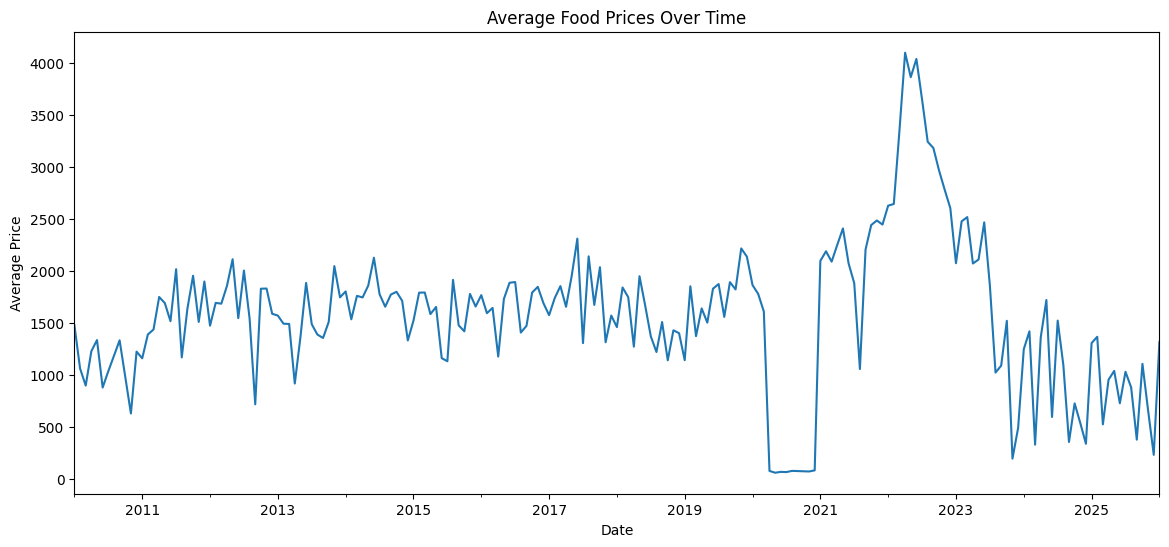

In [114]:
plt.figure(figsize=(14,6))

monthly_prices = food_df.groupby('date')['price'].mean()

monthly_prices.plot()

plt.title("Average Food Prices Over Time")
plt.xlabel("Date")
plt.ylabel("Average Price")

plt.show()

## 2. Average Prices by Commodity

This analysis compares the average prices of different commodities.

In [115]:
important_commodities = [
    'Maize',
    'Beans',
    'Milk (cow, pasteurized)'
]

filtered_df = food_df[
    food_df['commodity'].isin(important_commodities)
]

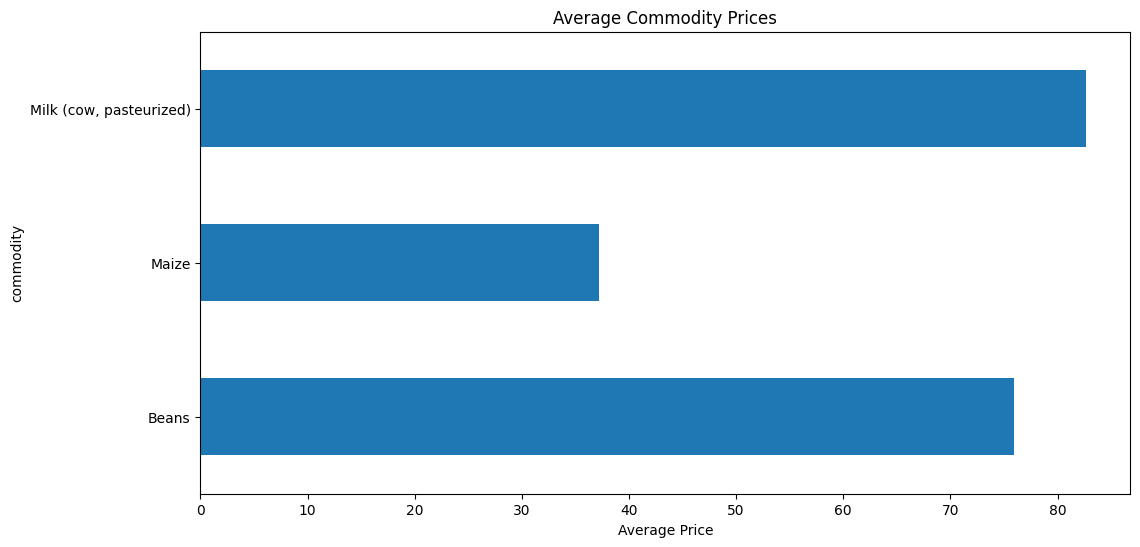

In [116]:
plt.figure(figsize=(12,6))

commodity_avg = filtered_df.groupby('commodity')['price'].mean()

commodity_avg.plot(kind='barh')

plt.title("Average Commodity Prices")
plt.xlabel("Average Price")

plt.show()

## 3. Relationship Between Rainfall and Food Prices

This visualization examines the relationship between rainfall levels and food prices.

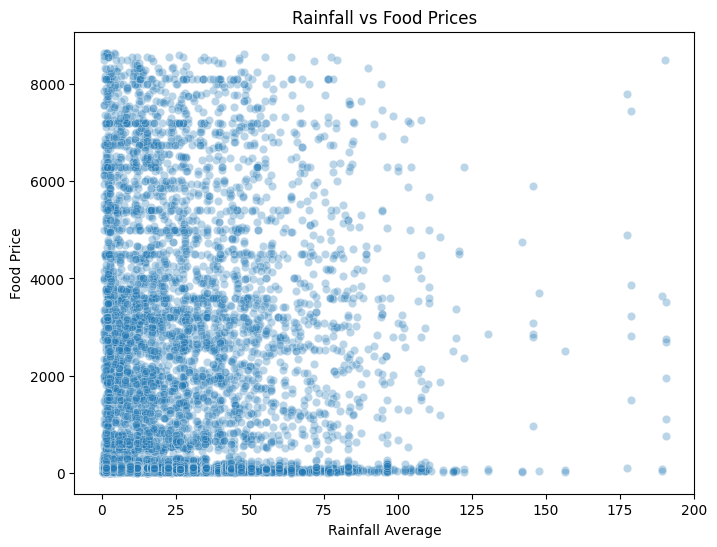

In [117]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x=merged_df['rfh'],
    y=merged_df['price'],
     alpha=0.3
)

plt.title("Rainfall vs Food Prices")

plt.xlabel("Rainfall Average")

plt.ylabel("Food Price")

plt.show()

###  Lag Diesel Price

Creating a 1-month lag for `diesel_price`. This allows the model to capture the influence of previous month's fuel prices on current food prices, accounting for potential delays in price adjustments across the supply chain.

In [118]:
# Sorting the DataFrame by 'admin2' and 'date' to ensure correct lagging within each region
merged_df = merged_df.sort_values(by=['admin2', 'date'])

# Creating a 1-month lagged diesel price column
merged_df['diesel_price_lag_1'] = merged_df.groupby('admin2')['diesel_price'].shift(1)

# Dropping rows where the lagged diesel price is NaN (first entry for each admin2)
merged_df.dropna(subset=['diesel_price_lag_1'], inplace=True)

print("DataFrame with 1-month lagged diesel price:")
display(merged_df.head())

DataFrame with 1-month lagged diesel price:


,date,admin2,commodity,pricetype,price,year_x,month_x,diesel_price,year_y,month_y,rfh,r3q,r3q_lag_3,year,month,diesel_price_lag_1
1528,2015-02-01,Baringo,Maize (white),Retail,47.0,2015,2,89.10,2015.0,2.0,5.810128,73.369926,92.445252,2015,2,88.20
1559,2015-03-01,Baringo,Maize (white),Retail,38.0,2015,3,76.20,2015.0,3.0,7.358190,41.034449,77.063410,2015,3,89.10
1584,2015-04-01,Baringo,Beans (dry),Retail,105.0,2015,4,77.48,2015.0,4.0,59.231419,84.964367,52.323890,2015,4,76.20
1585,2015-04-01,Baringo,Maize (white),Retail,42.0,2015,4,77.48,2015.0,4.0,59.231419,84.964367,52.323890,2015,4,77.48
1616,2015-05-01,Baringo,Beans (dry),Retail,106.0,2015,5,79.34,2015.0,5.0,38.508437,91.392305,61.165903,2015,5,77.48


## 4. Fuel Prices vs Food Prices

This analysis investigates how fuel prices influence food commodity prices.

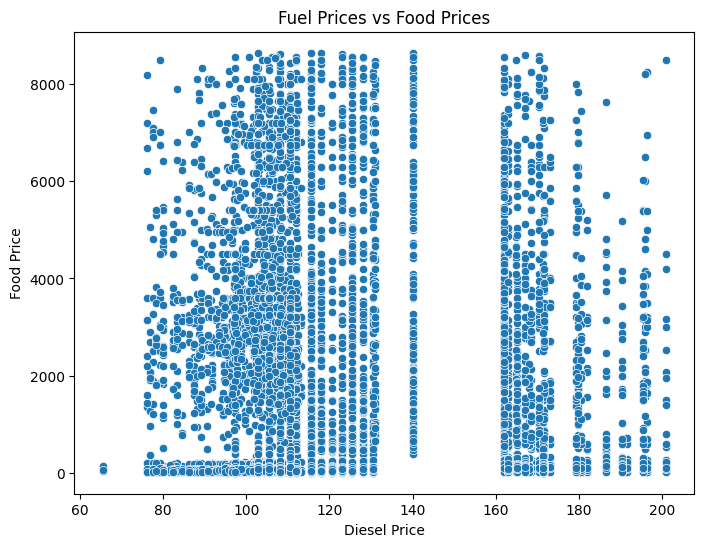

In [119]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x=merged_df['diesel_price'],
    y=merged_df['price']
)

plt.title("Fuel Prices vs Food Prices")

plt.xlabel("Diesel Price")

plt.ylabel("Food Price")

plt.show()

## 5. Correlation Analysis

The correlation heatmap is used to identify relationships between numerical variables.

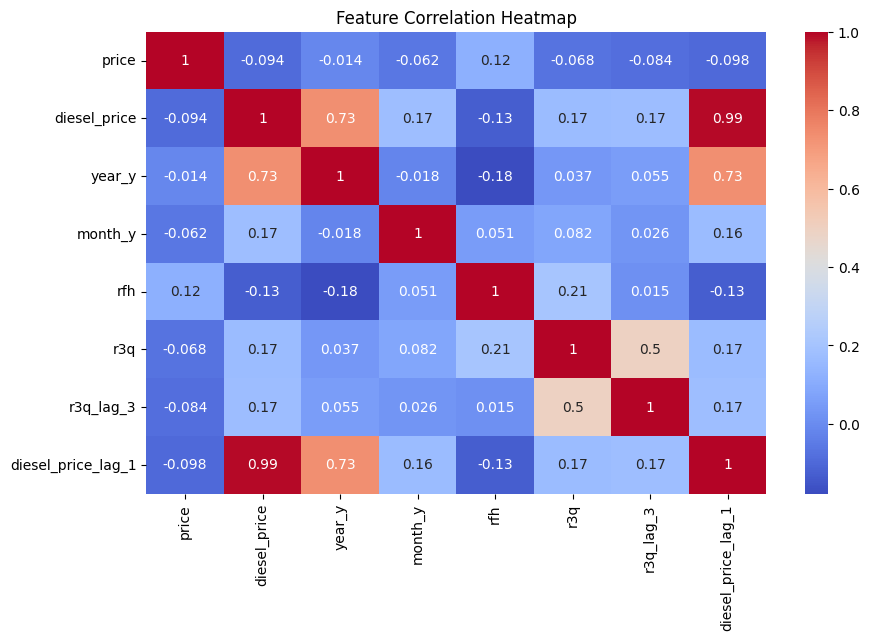

In [120]:
plt.figure(figsize=(10,6))

numeric_df = merged_df.select_dtypes(include=['int64', 'float64'])

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title("Feature Correlation Heatmap")

plt.show()

## 6.Seasonal Price Analysis

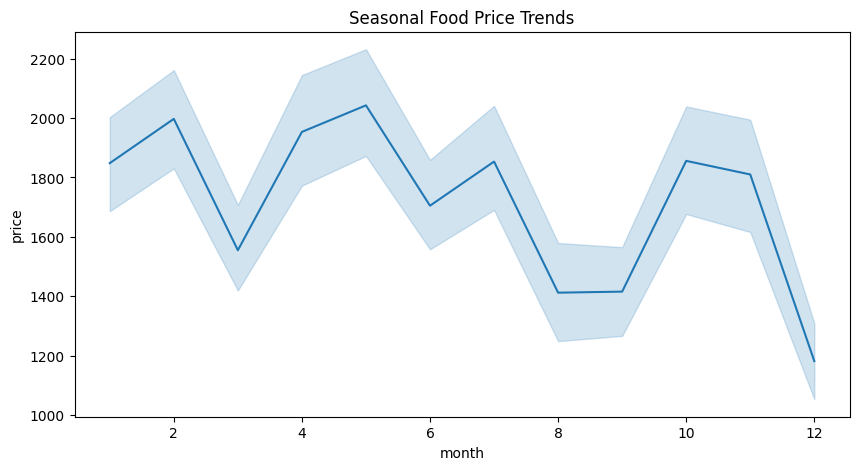

In [121]:
plt.figure(figsize=(10,5))

sns.lineplot(
    x='month',
    y='price',
    data=merged_df
)

plt.title("Seasonal Food Price Trends")

plt.show()

# Key Insights from EDA

The exploratory analysis revealed several important findings:

- Food prices generally increased over time
- Certain commodities consistently showed higher prices
- Rainfall patterns may influence food prices
- Fuel prices appear to affect commodity pricing
- Strong correlations exist between fuel-related variables
- Seasonal patterns are visible in commodity pricing trends

These insights support the use of machine learning models for food price forecasting.

# Modelling🤖🚀

In [122]:
import statsmodels.api as sm
from sklearn.metrics import mean_absolute_error,root_mean_squared_error
from sklearn.model_selection import train_test_split,cross_val_score
from sklearn.preprocessing import StandardScaler,OneHotEncoder,LabelEncoder
from sklearn.linear_model import LinearRegression

## Pre-process data  
Split into train and test data  
Standardise the numeric columns  
Perfom one hot encoding   


## 1.Split into train and test data


Firstly, we define our features (X) and our target variable (y). We will then split them into training and testing sets using an 80/20 ratio.

In [123]:
# Defining features (X) and target (y)
X = merged_df[['admin2', 'commodity', 'pricetype', 'year', 'month', 'rfh', 'r3q_lag_3', 'diesel_price_lag_1']]
y = merged_df['price']

# Splitting the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Shape of X_train:", X_train.shape)
print("Shape of X_test:", X_test.shape)
print("Shape of y_train:", y_train.shape)
print("Shape of y_test:", y_test.shape)

Shape of X_train: (7118, 8)
Shape of X_test: (1780, 8)
Shape of y_train: (7118,)
Shape of y_test: (1780,)


## 2. Standardize Numerical Columns

We will use `StandardScaler` to transform the numerical features in `X_train` and `X_test`. This step is essential to ensure that features with larger numerical values do not disproportionately influence the model.

In [124]:
numeric_features = ['year', 'month', 'rfh', 'r3q_lag_3', 'diesel_price_lag_1']

scaler = StandardScaler()

# Fitting on X_train's numeric features and transformming both X_train and X_test
X_train[numeric_features] = scaler.fit_transform(X_train[numeric_features])
X_test[numeric_features] = scaler.transform(X_test[numeric_features])

print("X_train after standardization:")
display(X_train.head())

print("X_test after standardization:")
display(X_test.head())

X_train after standardization:


,admin2,commodity,pricetype,year,month,rfh,r3q_lag_3,diesel_price_lag_1
3254,Kitui,Potatoes (Irish),Wholesale,-0.136583,1.048177,1.738481,0.668445,-0.766597
1049,Kisumu,Beans (dry),Wholesale,-1.541496,0.183877,-0.073784,0.370158,-0.771458
7460,Mandera,Spinach,Retail,1.034177,-0.968522,-0.802746,6.410074,1.919463
3711,Mombasa,Sorghum (red),Wholesale,0.331721,-1.256622,-0.813298,-0.514890,-0.739864
5202,Nairobi,"Potatoes (Irish, white)",Wholesale,0.331721,1.048177,-0.498886,0.657319,-0.051489


X_test after standardization:


,admin2,commodity,pricetype,year,month,rfh,r3q_lag_3,diesel_price_lag_1
1360,Nairobi,Fuel (diesel),Retail,-1.307344,0.183877,-0.879441,-1.089573,-0.570960
1502,Kisumu,Beans (dry),Wholesale,-1.073191,-1.544722,-0.818257,0.168679,-1.184604
4199,Wajir,Wheat flour,Retail,0.331721,-0.680422,0.219881,-1.081375,-0.583111
6284,West Pokot,Cabbage,Wholesale,0.565873,0.760077,-0.058602,-0.807154,1.148459
1950,Uasin Gishu,Maize (white),Wholesale,-0.839039,-0.968522,-0.037850,0.364937,-1.169415


## 3. Perform One-Hot Encoding

We will use `OneHotEncoder` to convert categorical features (`admin2`, `commodity`, `pricetype`) into a format that can be provided to machine learning algorithms. This creates new binary columns for each category.

In [125]:
categorical_features = ['admin2', 'commodity', 'pricetype']

encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)

# Fitting on X_train's categorical features and transform both X_train and X_test
X_train_encoded = encoder.fit_transform(X_train[categorical_features])
X_test_encoded = encoder.transform(X_test[categorical_features])

# Converting encoded arrays to DataFrames
X_train_encoded_df = pd.DataFrame(
    X_train_encoded,
    columns=encoder.get_feature_names_out(categorical_features),
    index=X_train.index
)
X_test_encoded_df = pd.DataFrame(
    X_test_encoded,
    columns=encoder.get_feature_names_out(categorical_features),
    index=X_test.index
)

# Dropping original categorical columns and concatenate the encoded ones
X_train = pd.concat([X_train.drop(columns=categorical_features), X_train_encoded_df], axis=1)
X_test = pd.concat([X_test.drop(columns=categorical_features), X_test_encoded_df], axis=1)

print("X_train after one-hot encoding:")
display(X_train.head())

print("X_test after one-hot encoding:")
display(X_test.head())

X_train after one-hot encoding:


,year,month,rfh,r3q_lag_3,diesel_price_lag_1,admin2_Baringo,admin2_Garissa,admin2_Isiolo,admin2_Kajiado,admin2_Kilifi,...,commodity_Salt,commodity_Sorghum,commodity_Sorghum (red),commodity_Sorghum (white),commodity_Spinach,commodity_Sugar,commodity_Tomatoes,commodity_Wheat flour,pricetype_Retail,pricetype_Wholesale
3254,-0.136583,1.048177,1.738481,0.668445,-0.766597,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1049,-1.541496,0.183877,-0.073784,0.370158,-0.771458,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
7460,1.034177,-0.968522,-0.802746,6.410074,1.919463,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
3711,0.331721,-1.256622,-0.813298,-0.514890,-0.739864,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
5202,0.331721,1.048177,-0.498886,0.657319,-0.051489,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


X_test after one-hot encoding:


,year,month,rfh,r3q_lag_3,diesel_price_lag_1,admin2_Baringo,admin2_Garissa,admin2_Isiolo,admin2_Kajiado,admin2_Kilifi,...,commodity_Salt,commodity_Sorghum,commodity_Sorghum (red),commodity_Sorghum (white),commodity_Spinach,commodity_Sugar,commodity_Tomatoes,commodity_Wheat flour,pricetype_Retail,pricetype_Wholesale
1360,-1.307344,0.183877,-0.879441,-1.089573,-0.570960,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
1502,-1.073191,-1.544722,-0.818257,0.168679,-1.184604,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
4199,0.331721,-0.680422,0.219881,-1.081375,-0.583111,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0
6284,0.565873,0.760077,-0.058602,-0.807154,1.148459,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1950,-0.839039,-0.968522,-0.037850,0.364937,-1.169415,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


## 4. Training Linear Regression Model

We trained a Linear Regression model using the preprocessed training data (`X_train`, `y_train`). Linear Regression is a fundamental supervised learning algorithm used for predictive analysis, which models the relationship between a dependent variable and one or more independent variables by fitting a linear equation to the observed data.

In [126]:
model = LinearRegression()

# Train the model
model.fit(X_train, y_train)

print("Linear Regression model trained successfully.")

Linear Regression model trained successfully.


## 5. Making Predictions and Evaluating the Model

After training, we will use the model to make predictions on the test set (X_test) and evaluate its performance using metrics such as Mean Absolute Error (MAE) and Root Mean Squared Error (RMSE). These metrics provide a measure of how close the model's predictions are to the actual values.

In [127]:
# Making predictions on the test set
y_pred = model.predict(X_test)

# Evaluating the model
mae = mean_absolute_error(y_test, y_pred)
rmse = root_mean_squared_error(y_test, y_pred)

print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")

Mean Absolute Error (MAE): 632.37
Root Mean Squared Error (RMSE): 906.77


## 6. Training Random Forest Regressor Model

We will now train a Random Forest Regressor model, which is an ensemble learning method that builds multiple decision trees and merges them together to get a more accurate and stable prediction. This is often more robust to outliers and can capture non-linear relationships in the data.

In [128]:
from sklearn.ensemble import RandomForestRegressor

# Initialize the Random Forest Regressor
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)

# Train the model
rf_model.fit(X_train, y_train)

# print("Random Forest Regressor model trained successfully.")

RandomForestRegressor(random_state=42)

## 7. Making Predictions and Evaluating Random Forest Model

After training the Random Forest Regressor, we will make predictions on the test set (`X_test`) and evaluate its performance using Mean Absolute Error (MAE) and Root Mean Squared Error (RMSE) to compare with the Linear Regression model.

In [129]:
# Making predictions on the test set
y_pred_rf = rf_model.predict(X_test)

# Evaluating the model
mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = root_mean_squared_error(y_test, y_pred_rf)

print(f"Random Forest Regressor - Mean Absolute Error (MAE): {mae_rf:.2f}")
print(f"Random Forest Regressor - Root Mean Squared Error (RMSE): {rmse_rf:.2f}")

Random Forest Regressor - Mean Absolute Error (MAE): 215.42
Random Forest Regressor - Root Mean Squared Error (RMSE): 446.38
